<a href="https://colab.research.google.com/github/soda1102/AI_26/blob/main/AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1%EB%B0%8F%EB%B6%84%EC%84%9D(%EA%B9%80%EC%86%8C%ED%98%84).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
# 더미데이터 전처리
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42)

In [94]:
# 훈련, 테스트, 검증 데이터 shape
print("훈련데이터 : ")
print(train_scaled.shape, train_target.shape)

print("테스트데이터 : ")
print(test_input.shape, test_target.shape)

print("검증데이터 : ")
print(val_scaled.shape, val_target.shape)

훈련데이터 : 
(48000, 28, 28, 1) (48000,)
테스트데이터 : 
(10000, 28, 28) (10000,)
검증데이터 : 
(12000, 28, 28, 1) (12000,)


In [95]:
# 모델용 객체 함수 생성(model_fn() 함수 사용)
def model_fn(a_layer = None) :
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape = (28, 28)))
  model.add(keras.layers.Dense(100, activation = 'relu'))

  # model_fn() 함수에 (a_layer 매개변수) 케라스 층 추가 시 은닉층 뒤에 하나의 층 추가
  if a_layer:
    model.add(a_layer)

  # 반복적으로 사용되는 다중분류
  model.add(keras.layers.Dense(10, activation = 'softmax'))
  return model

In [96]:
# 메서드 호출 → 모델에 담기
model = model_fn()

# 모델 요약정보 확인
model.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_31 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# 다중분류를 이용한 컴파일 (sparse_categorical_crossentropy : 다중분류, accuracy : 정확도)
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [98]:
# 훈련시작(fit() 함수 사용, epochs 5번(반복), verbose 1 사용하여 진행막대 지표 함께 출력)
history = model.fit(train_scaled, train_target, epochs = 5, verbose = 1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7620 - loss: 0.6785
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8521 - loss: 0.4056
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8686 - loss: 0.3600
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8788 - loss: 0.3362
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3192


In [99]:
# history 변수 확인
print(history)

In [100]:
# 훈련 측정 값 확인(정확도, 손실값)
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


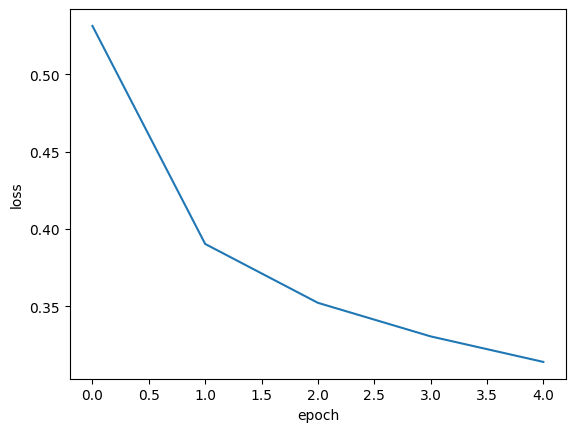

In [101]:
# histoty 안에 있는 정확도, 손실률 그래프 확인
import matplotlib.pyplot as plt

# 손실률 그래프 먼저 확인
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

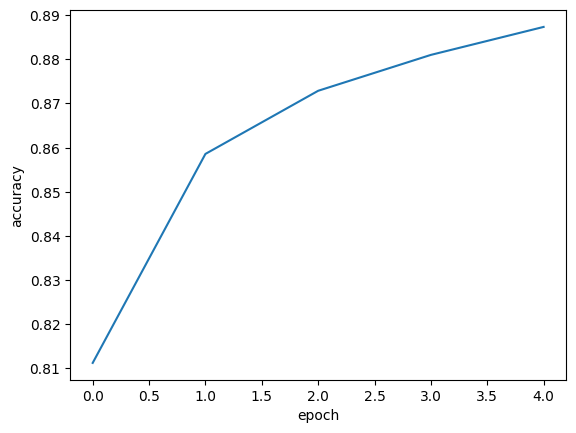

In [102]:
# 정확도 그래프 확인
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [103]:
# 에포크 횟수 30번으로 늘려서 시도
model = model_fn()
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 15, verbose = 1)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7639 - loss: 0.6860
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8497 - loss: 0.4148
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8668 - loss: 0.3680
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8765 - loss: 0.3408
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8848 - loss: 0.3195
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8912 - loss: 0.3052
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8958 - loss: 0.2926
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2836
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9039 - loss: 0.2760
Epoch 10/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9074 - loss: 0.2676
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9094 - loss: 0.2600
Epoch 12/15
1500/1500 ━━━━━━━━

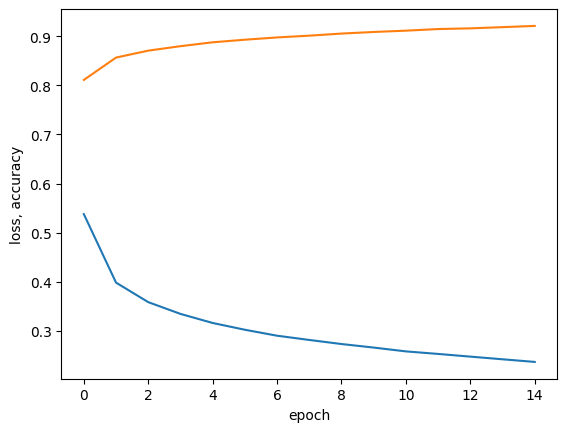

In [104]:
# 손실률과 정확도 그래프 확인
plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])

plt.xlabel('epoch')
plt.ylabel('loss, accuracy')

plt.show()

In [105]:
# 검증 손실로 과대, 과소 적합 응용
model = model_fn()
model.summary()
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 15, verbose = 1, validation_data = (val_scaled, val_target))

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_33 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7609 - loss: 0.6817 - val_accuracy: 0.8484 - val_loss: 0.4271
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8512 - loss: 0.4081 - val_accuracy: 0.8586 - val_loss: 0.3910
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8686 - loss: 0.3628 - val_accuracy: 0.8598 - val_loss: 0.3859
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8755 - loss: 0.3391 - val_accuracy: 0.8621 - val_loss: 0.3755
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8849 - loss: 0.3211 - val_accuracy: 0.8603 - val_loss: 0.3916
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8915 - loss: 0.3082 - val_accuracy: 0.8658 - val_loss: 0.3957
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8952 - loss: 0.2964 - val_accuracy: 0.8652 - val_loss: 0.3949
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8999 - loss: 0.2868 - 

In [106]:
# 훈련 측정 값 확인(정확도, 손실률, 검증세트 정확도, 검증세트 손실)
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


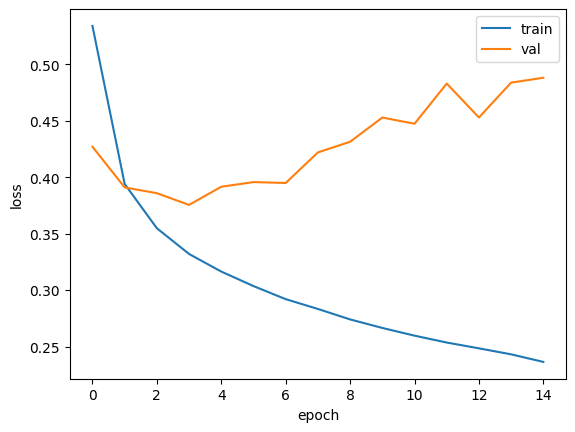

In [107]:
# 훈련 손실, 검증 손실 그래프에 비교
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])

plt.show()

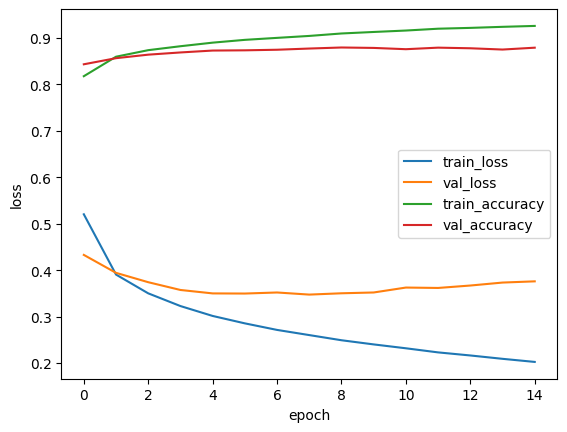

In [108]:
# 최적화 기법 Adam 사용
model = model_fn()

model.compile(optimizer = 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 15, verbose = 0, validation_data = (val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

plt.show()

In [109]:
# 과대적합 막기(Dropout 사용 - 뉴런 출력을 0 으로 만들어서 막음)
# 40%로 과대적합 막아보기(드롭아웃)

model = model_fn(keras.layers.Dropout(0.4))

model.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_35 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

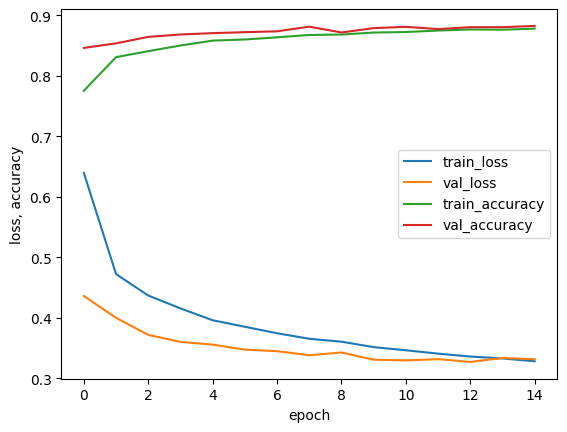

In [110]:
# Adam 기법

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 15, verbose = 0, validation_data = (val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

plt.show()

In [111]:
# 모델 저장(adam)
model = model_fn(keras.layers.Dropout(0.4))
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 15, verbose = 0, validation_data = (val_scaled, val_target))

model.save('model-adam-ep15.keras')
model.save_weights('model_adam.weights.h5')

In [112]:
# 모델을 불러와 테스트 점수 확인(adam)

model = keras.models.load_model('model-adam-ep15.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8824 - loss: 0.3259


[0.3279492259025574, 0.8788333535194397]

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7201 - loss: 0.8002 - val_accuracy: 0.8460 - val_loss: 0.4344
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8299 - loss: 0.4789 - val_accuracy: 0.8537 - val_loss: 0.4021
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8436 - loss: 0.4348 - val_accuracy: 0.8638 - val_loss: 0.3693
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8484 - loss: 0.4153 - val_accuracy: 0.8686 - val_loss: 0.3572
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8551 - loss: 0.3919 - val_accuracy: 0.8683 - val_loss: 0.3559
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8596 - loss: 0.3859 - val_accuracy: 0.8747 - val_loss: 0.3425
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8640 - loss: 0.3698 - val_accuracy: 0.8733 - val_loss: 0.3452
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8666 - loss: 0.3589 - 

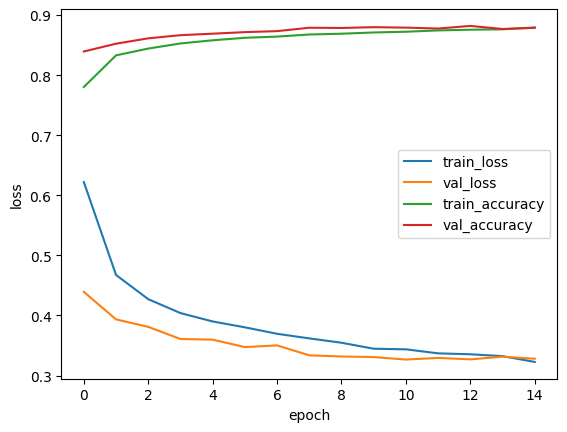

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8804 - loss: 0.3211


[0.3274387717247009, 0.8794999718666077]

In [113]:
# 모델 컴파일과 훈련(adam)
import matplotlib.pyplot as plt

model = model_fn(keras.layers.Dropout(0.4))

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

model.fit(train_scaled, train_target, epochs = 15, verbose = 1, validation_data = (val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

model.evaluate(val_scaled, val_target)

In [114]:
# 최적화(아담 사용)
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 2, restore_best_weights = True)

history = model.fit(train_scaled, train_target, epochs = 15,
                    validation_data = (val_scaled, val_target))

model.evaluate(val_scaled, val_target)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8789 - loss: 0.3219 - val_accuracy: 0.8824 - val_loss: 0.3279
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8833 - loss: 0.3149 - val_accuracy: 0.8802 - val_loss: 0.3305
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8839 - loss: 0.3103 - val_accuracy: 0.8807 - val_loss: 0.3318
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8844 - loss: 0.3080 - val_accuracy: 0.8836 - val_loss: 0.3218
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8840 - loss: 0.3076 - val_accuracy: 0.8838 - val_loss: 0.3214
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8858 - loss: 0.3022 - val_accuracy: 0.8825 - val_loss: 0.3290
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8874 - loss: 0.2997 - val_accuracy: 0.8861 - val_loss: 0.3282
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8855 - loss: 0.2964 - 

[0.32824084162712097, 0.8870000243186951]

In [115]:
# 모델 불러와서 테스트 점수 확인
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8799 - loss: 0.3631


[0.3677320182323456, 0.8784999847412109]

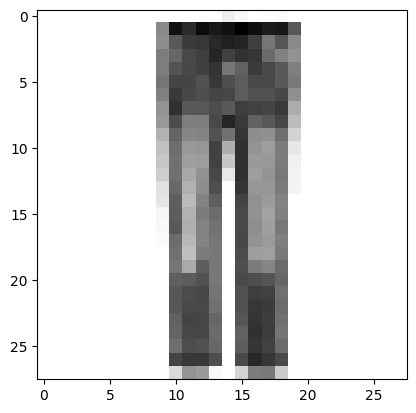

In [116]:
plt.imshow(test_scaled[15].reshape(28, 28), cmap = 'gray_r')
plt.show()